In [33]:
import os
import h5py
import numpy as np
from scipy.integrate import solve_ivp
from scipy.stats.qmc import Halton
from time import time
import torch
import matplotlib.pyplot as plt
# from joblib import Parallel, delayed  # For parallel execution
import pandas as pd



In [2]:
# File paths
# old_file_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/Old equations/datasets/trials_many_alldata_v3.h5"
new_file_path = "datasets/trials_many_alldata_new_eqution_halton_3000.h5"

In [3]:
# with h5py.File(old_file_path, 'r') as old_data:
#     # Extract parameter values
#     P_old = old_data['P'][:]
#     J_e_primes = P_old[:, 0]
#     b_1_primes = P_old[:, 1]
#     b_2_primes = P_old[:, 2]
#     f_0_primes = P_old[:, 6]

#     # Find the shortest length
#     min_length = min(len(J_e_primes), len(b_1_primes), len(b_2_primes), len(f_0_primes))
#     # Function to randomly reduce the length of a list
#     def reduce_length(arr, target_length):
#         if len(arr) > target_length:
#             indices = np.random.choice(len(arr), target_length, replace=False)
#             return arr[indices]
#         return arr

#     # Reduce lengths to the shortest length
#     J_e_primes = reduce_length(J_e_primes, min_length)
#     b_1_primes = reduce_length(b_1_primes, min_length)
#     b_2_primes = reduce_length(b_2_primes, min_length)
#     f_0_primes = reduce_length(f_0_primes, min_length)
#     f_cr = 5.3e-3
#     f_0_values = f_0_primes/f_cr
#     # h_0_values = P_old[:, 4]

# time_grid = np.linspace(0, 1, 601)

In [4]:
# print(J_e_primes.min(), J_e_primes.max())
# print(b_1_primes.min(), b_1_primes.max())
# print(b_2_primes.min(), b_2_primes.max())
# print(f_0_values.min(), f_0_values.max())
# print(h_0_values.min(), h_0_values.max())

Constants

In [ ]:
halton_sampler = Halton(d=1, scramble=False, seed=42)
halton_sequence = halton_sampler.random(n=111563).flatten()

ts_range = [10., 60.] # Characteristic time scale (s)
ts_halton = ts_range[0] + (ts_range[1] - ts_range[0]) * halton_sequence

h_range = [2e-6, 8e-6] # Characteristic height (m)
h_0_values = h_range[0] + (h_range[1] - h_range[0]) * halton_sequence

J_e_range = [0., 40e-6] # Characteristic evaporation rate (m/minute)
J_e_primes = J_e_range[0] + (J_e_range[1] - J_e_range[0]) * halton_sequence
J_e_primes = J_e_primes / 60. # Convert to m/s
# J_e_values = J_e_primes * ts_halton / h_0_values

f_0_range = [0.08 / 100, 0.2 / 100]  # Characteristic fluorescence (%)
f_cr = 5.3e-3 # Critical fluorescence (%)
f_cr = 0.002
f_0_primes = f_0_range[0] + (f_0_range[1] - f_0_range[0]) * halton_sequence
# f_0_values = f_0_primes / f_cr

b_1_range = [-0.25, 2.] # (s^-1)
b_1_primes = b_1_range[0] + (b_1_range[1] - b_1_range[0]) * halton_sequence
# b_1_values = b_1_primes * ts_halton

b_2_range = [0., 2.] # (s^-1)
b_2_primes = b_2_range[0] + (b_2_range[1] - b_2_range[0]) * halton_sequence
# b_2_values = b_2_primes * ts_halton

# Rescale to be in the range 0.5 to 1.0
h_e_range = [0.5e-6, 1e-6] # Characteristic height (m)
h_e_halton = h_e_range[0] + (h_e_range[1] - h_e_range[0]) * halton_sequence
# h_e_values = np.array(h_e_halton) / np.array(h_0_values)


In [55]:
def make_nondimensional(values):
# def make_nondimensional(h0, ts, Je_pr, f0_pr, b1_pr, b2_pr, he_pr):
    # f_cr = 5.3e-3 # Critical fluorescence (%)
    f_cr = 2e-3
    rho = 1e0 # Water density (kg/L)
    P_c_hat = 12.1e-6 # (m/s)
    Vw = 18e-6 # Molar volume of water (m^3/Mol)
    c_0 = 300 # Serum Osmolarity (Mol/m^3)
    sigma_0 = 0.045 # N/m
    mu = 1.3e-3 # Pa.s

    # Solute parameters
    Mw_FL = 376e-3 # molecular weight of Na_2FL, (Kg/mol)

    # Naperian extinction coefficient
    eps_f = 1.75e7 # m^-1 M^-1
    # transmittance parameter
    fcr2 = rho * f_cr/Mw_FL
    
    ts, h0 = values["t_s"], values["h_0"]
    Je = values["J_e"] * ts/ h0
    f0 = values["f_0"] / f_cr
    b1 = values["b_1"] * ts
    b2 = values["b_2"] * ts
    he = values["h_e"]/ h0
    phi = eps_f*fcr2*h0
    Pc = P_c_hat*Vw*c_0 * (ts/h0)

    return Je, f0, b1, b2, he, phi, Pc


In [ ]:
# rho = 1e3 # Water density (g/L)
# P_c_hat = 12.1e-6 # (m/s)
# Vw = 18e-6 # Molar volume of water (m^3/Mol)
# c_0 = 300 # Serum Osmolarity (Mol/m^3)
# sigma_0 = 0.045 # N/m
# mu = 1.3e-3 # Pa.s

# # Solute parameters
# Mw_FL = 376e-3 # molecular weight of Na_2FL, (Kg/mol)

# # Naperian extinction coefficient
# eps_f = 1.75e7 # m^-1 M^-1
# # transmittance parameter
# fcr2 = rho * f_cr/Mw_FL

# # phi_values = eps_f*fcr2*h_0_values
# # Pc_values = P_c_hat*Vw*c_0/(h_0_values/ts_halton)

In [50]:

dimensional = pd.DataFrame({
    't_s': ts_halton,
    'J_e': J_e_primes,
    'b_1': b_1_primes,
    'b_2': b_2_primes,
    'f_0': f_0_primes,
    'h_0': h_0_values,
    'h_e': h_e_halton
})

In [99]:
# Differential system (P_c is a constant and does not need to be passed as an argument)
def differential_system(t, y, J_e, b_1, b_2, h_e, P_c):
    h, c = y
    g_t = b_1 * np.exp(-b_2 * t)
    dh_dt = -g_t * h - J_e * (1 - (h_e / h) ** 3) + P_c * (c - 1)
    dc_dt = -g_t * c - dh_dt * (c / h)
    return [dh_dt, dc_dt]

def solve_system(J_e, b_1, b_2, h_e, f_0, Pc, phi ):
    y0 = [1.0, 1.0]
    t = np.linspace(0, 1, 601)
    sol = solve_ivp(differential_system, [0., 1.], y0, t_eval=t, 
                    args=(J_e, b_1, b_2, h_e, Pc), method='BDF', dense_output=True)  # Faster for stiff equations
    
    if np.max(sol.y[0]) > 1.1:
        raise ValueError("Solution exceeds maximum allowed value for h.")
    elif sol.y[0].shape[0] < 601:
        raise ValueError("Solution ended prematurely.")
    else:
        h = sol.y[0]
        c = sol.y[1] 
        f = f_0 * c
        FI = ((-np.exp(-phi * f * sol.y[0])) + 1) / ((f ** 2) + 1)
        I0 = 1 / FI[1]
        I = I0 * ((-np.exp(-phi * f * sol.y[0])) + 1) / ((f ** 2) + 1)
        return t, h, c, f, I, sol

# Function to calculate I
def calculate_I(h, f, phi, I_0=1.0):
    return I_0 * (1 - np.exp(-phi * h * f)) / (1 + f ** 2)


nondimensional values:
J_e:  1.2499999999999998
f_0:  6.0
b_1:  18.0
b_2:  36.0
h_e:  0.16666666666666666
phi:  0.5585106382978723
Pc:  0.3267

dimensional values:
t_s    3.000000e+01
J_e    2.500000e-07
b_1    6.000000e-01
b_2    1.200000e+00
f_0    1.200000e-02
h_0    6.000000e-06
h_e    1.000000e-06
dtype: float64


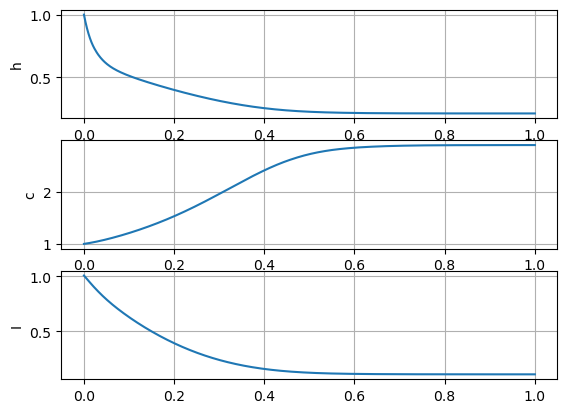

In [100]:
i = 10
primes = dimensional.iloc[i,:]

primes = pd.Series({
    't_s': 30,
    'J_e': 15 * 1e-6 / 60,
    'b_1': 0.6,
    'b_2': 1.2,
    'f_0': 0.012,
    'h_0': 6 * 1e-6,
    'h_e': 1 * 1e-6
})

J_e, f_0, b_1, b_2, h_e, phi, Pc = make_nondimensional(primes)
print("nondimensional values:")
print("J_e: ", J_e)
print("f_0: ", f_0)
print("b_1: ", b_1)
print("b_2: ", b_2)
print("h_e: ", h_e)
print("phi: ", phi)
print("Pc: ", Pc)
print("\ndimensional values:")
print(primes)

t, h, c, f, I, sol = solve_system(J_e, b_1, b_2, h_e, f_0, Pc, phi)
plt.subplot(3, 1, 1)
plt.plot(t, h, label='h')
plt.ylabel('h')
plt.grid()
plt.subplot(3, 1, 2)
plt.plot(t, c, label='c')
plt.ylabel('c')
plt.grid()
plt.subplot(3, 1, 3)
plt.plot(t, I, label='I')
plt.ylabel('I')
plt.grid()

In [68]:
h[::60]

array([1.        , 0.51013554, 0.39727568, 0.3100433 , 0.25143805,
       0.22320048, 0.21370026, 0.21050641, 0.20978292, 0.20966783,
       0.20962438])

In [69]:
c[::60]

array([ 1.        ,  2.36914539,  3.8564648 ,  6.32709062,  9.61096701,
       12.20395743, 13.32233032, 13.73064836, 13.82538874, 13.84057239,
       13.84631106])

In [85]:
differential_system(0.1, [0.3, 3.0], J_e, b_1, b_2, h_e, Pc)

0.49182700405126606


[np.float64(-0.5298133961399338), np.float64(3.8226529492455406)]

In [98]:
sol.values

<function OdeResult.values>

In [79]:
np.array([1.,1]) + sol.t[1]*np.array([np.float64(-19.244212962962962), np.float64(1.244212962962962)])

array([0.96792631, 1.00207369])

In [ ]:

def generate_and_store_dataset():  
    valid_h, valid_c, valid_f, valid_I, valid_p = [], [], [], [], []
    time_grid = np.linspace(0, 1, 601)  # Time grid for integration
    fixed_length = len(time_grid) 
    
    def solve_single_instance(i):
        J_e, b_1, b_2, h_e, f_0, Pc, phi = (J_e_values[i], b_1_values[i], b_2_values[i],
                                            h_e_values[i], f_0_values[i], Pc_values[i], phi_values[i])
        y0 = [1.0, 1.0]
        sol = solve_ivp(differential_system, [0., 1.], y0, t_eval=time_grid, 
                        args=(J_e, b_1, b_2, h_e, Pc), method='LSODA')  # Faster for stiff equations
        
        if np.max(sol.y[0]) > 1.1:
            return None  # Skip rejected cases
        elif sol.y[0].shape[0] < fixed_length:
            return None
        else:
            h = sol.y[0]
            c = sol.y[1] / sol.y[0]
            f = f_0 * c
            FI = ((-np.exp(-phi * f * sol.y[0])) + 1) / ((f ** 2) + 1)
            I0 = 1 / FI[1]
            I = I0 * ((-np.exp(-phi * f * sol.y[0])) + 1) / ((f ** 2) + 1)
            return h, c, f, I, (J_e, b_1, b_2, h_e, f_0, Pc, phi)

    results = Parallel(n_jobs=-1)(delayed(solve_single_instance)(i) for i in range(3000))
    filtered_results = [res for res in results if res is not None]
    print(len(filtered_results[0]))

    # Unpacking results into numpy arrays for efficient storage
    valid_h, valid_c, valid_f, valid_I, valid_p = map(np.array, zip(*filtered_results))

    # Convert lists to NumPy arrays
    valid_h = np.array(valid_h)
    valid_c = np.array(valid_c)
    valid_f = np.array(valid_f)
    valid_I = np.array(valid_I)
    valid_p = np.array(valid_p)

    # Save data in HDF5 format
    with h5py.File(new_file_path, "w") as hdf_file:
        hdf_file.create_dataset("h", data=valid_h)
        hdf_file.create_dataset("c", data=valid_c)
        hdf_file.create_dataset("f", data=valid_f)
        hdf_file.create_dataset("I", data=valid_I)
        hdf_file.create_dataset("p", data=valid_p)
        
    print(f"Total accepted parameter sets: {valid_h.shape[0]}")
    return valid_h, valid_c, valid_f, valid_I, valid_p


In [11]:
start = time()
valid_h, valid_c, valid_f, valid_I, valid_p = generate_and_store_dataset()
end = time()
print(f"Time taken: {end - start:.2f} seconds")

5
Total accepted parameter sets: 1666
Time taken: 41.65 seconds


In [12]:
datastore = h5py.File(new_file_path, 'r')
data_I = np.array(datastore["I"])
data_h = np.array(datastore["h"])
data_f = np.array(datastore["f"])

data_c = np.array(datastore["c"])

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
# device = "cpu"
print(f"Using {device} device")

Using cpu device


In [13]:
t = np.linspace(0,1,601)

In [23]:
argmin_je = np.argmin(J_e_values)

0
Parameters for n=0:
J_e: 0.0
b_1: -20.0
b_2: 0.0
h_e: 0.25
f_0: 15.09433962264151
P_c: 0.32670000000000005
phi: 493.35106382978717
ts_halton: 10.0


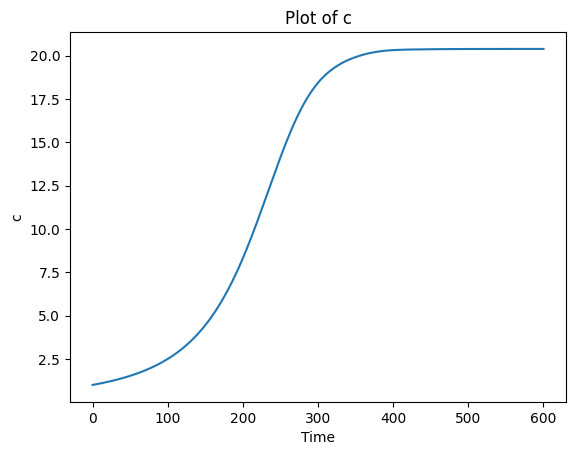

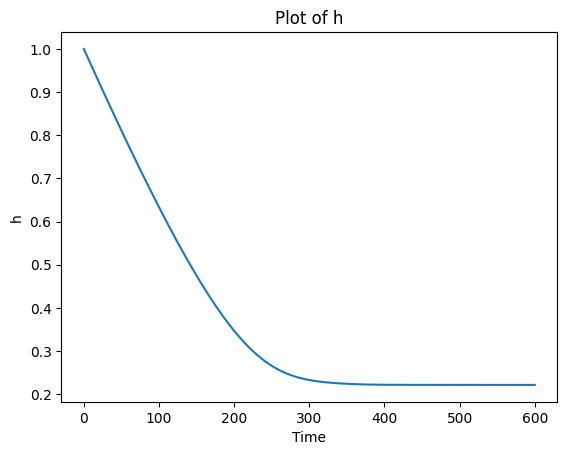

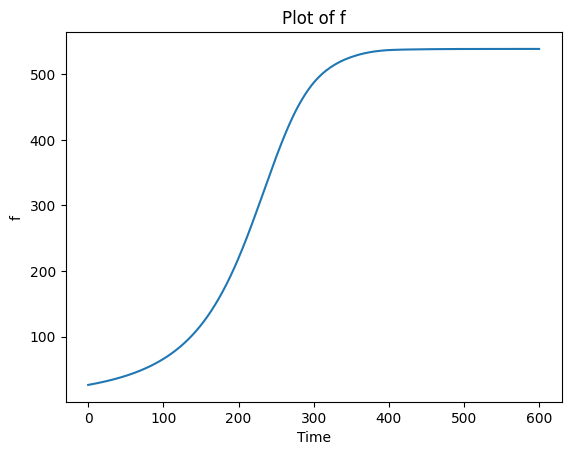

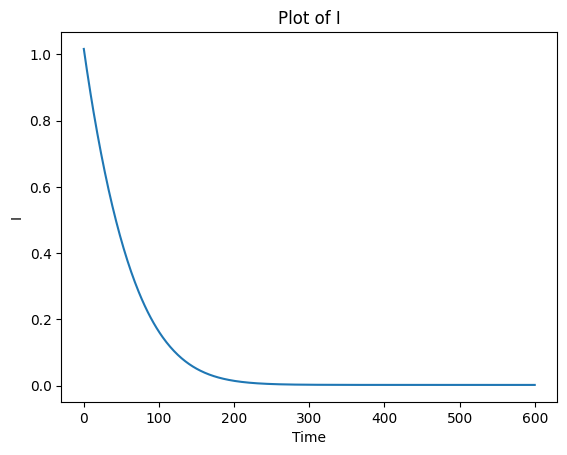

In [24]:
n = argmin_je
print(n)
print(f"Parameters for n={n}:")
print(f"J_e: {J_e_values[n]}")
print(f"b_1: {b_1_values[n]}")
print(f"b_2: {b_2_values[n]}")
print(f"h_e: {h_e_values[n]}")
print(f"f_0: {f_0_values[n]}")
print(f"P_c: {Pc_values[n]}")
print(f"phi: {phi_values[n]}")
print(f"ts_halton: {ts_halton[n]}")

plt.plot(data_c[n])
plt.title('Plot of c')
plt.xlabel('Time')
plt.ylabel('c')
plt.show()

plt.plot(data_h[n])
plt.title('Plot of h')
plt.xlabel('Time')
plt.ylabel('h')
plt.show()

plt.plot(data_f[n])
plt.title('Plot of f')
plt.xlabel('Time')
plt.ylabel('f')
plt.show()

plt.plot(data_I[n])
plt.title('Plot of I')
plt.xlabel('Time')
plt.ylabel('I')
plt.show()

362
Parameters for n=362:
J_e: 1.5042851297284192
b_1: -17.439422607421875
b_2: 18.174819946289062
h_e: 0.16610087293889425
f_0: 22.744693396226413
P_c: 0.43633937924345295
phi: 993.4471617353722
ts_halton: 26.89453125


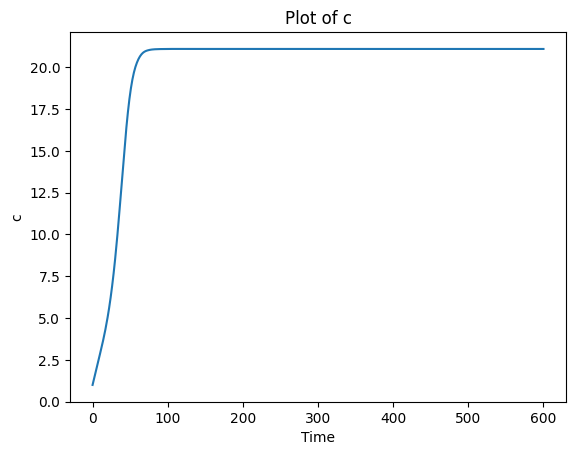

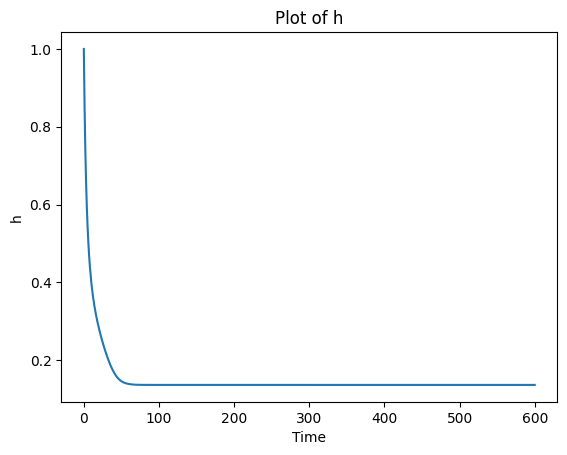

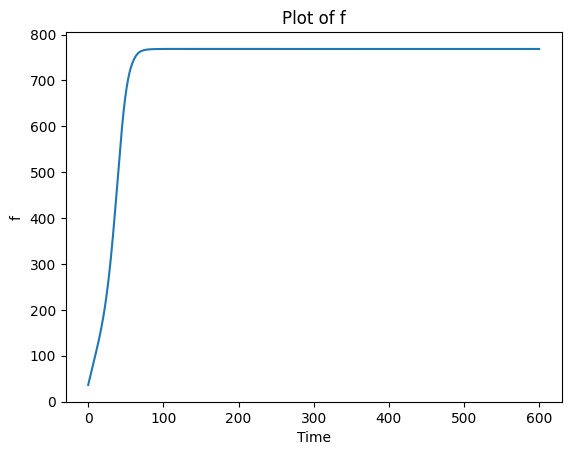

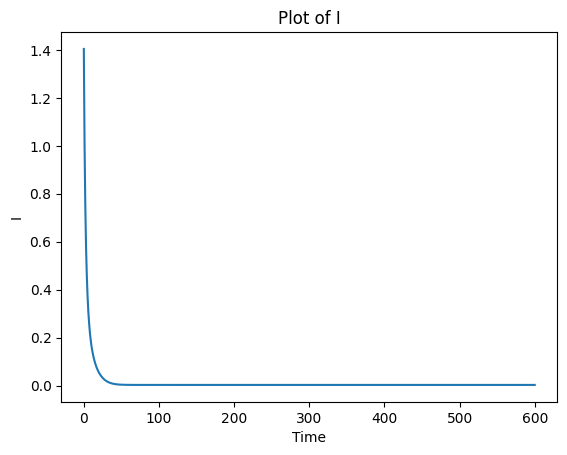

In [21]:
n = np.random.randint(0, len(data_h))
print(n)
print(f"Parameters for n={n}:")
print(f"J_e: {J_e_values[n]}")
print(f"b_1: {b_1_values[n]}")
print(f"b_2: {b_2_values[n]}")
print(f"h_e: {h_e_values[n]}")
print(f"f_0: {f_0_values[n]}")
print(f"P_c: {Pc_values[n]}")
print(f"phi: {phi_values[n]}")
print(f"ts_halton: {ts_halton[n]}")

plt.plot(data_c[n])
plt.title('Plot of c')
plt.xlabel('Time')
plt.ylabel('c')
plt.show()

plt.plot(data_h[n])
plt.title('Plot of h')
plt.xlabel('Time')
plt.ylabel('h')
plt.show()

plt.plot(data_f[n])
plt.title('Plot of f')
plt.xlabel('Time')
plt.ylabel('f')
plt.show()

plt.plot(data_I[n])
plt.title('Plot of I')
plt.xlabel('Time')
plt.ylabel('I')
plt.show()

1028
Parameters for n=1028:
J_e: 0.4945636057777581
b_1: -24.37983512878418
b_2: 4.08449649810791
h_e: 0.20441645973749556
f_0: 17.935583726415096
P_c: 0.3862685704150408
phi: 679.0803949883643


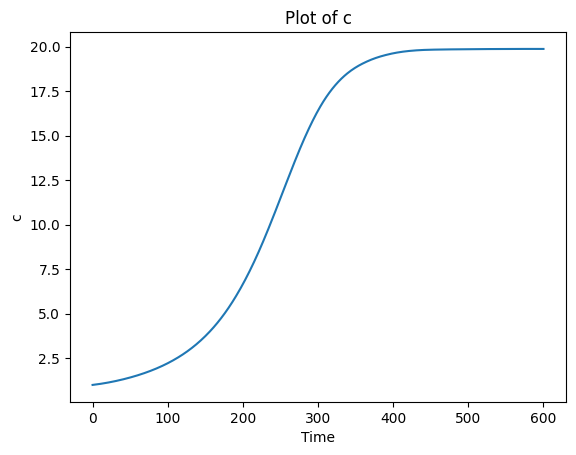

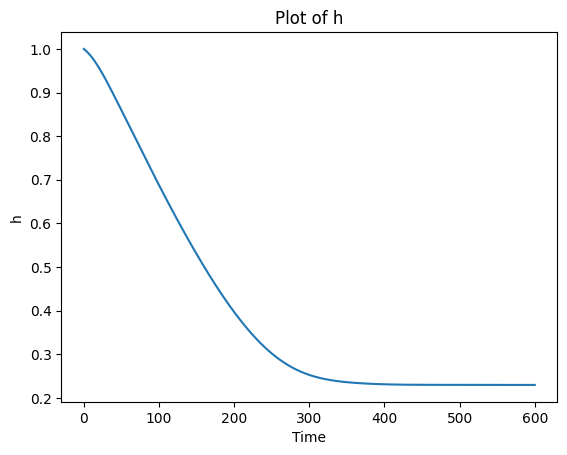

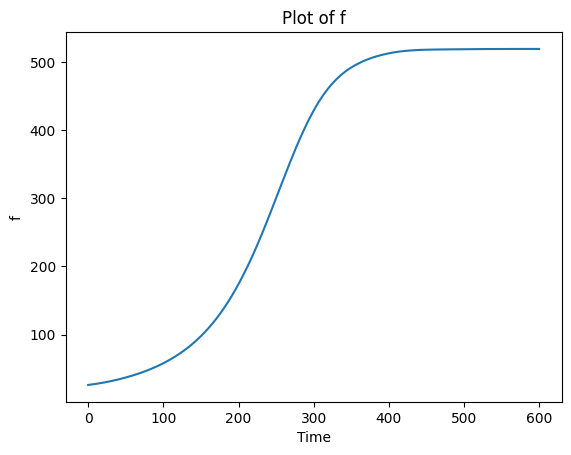

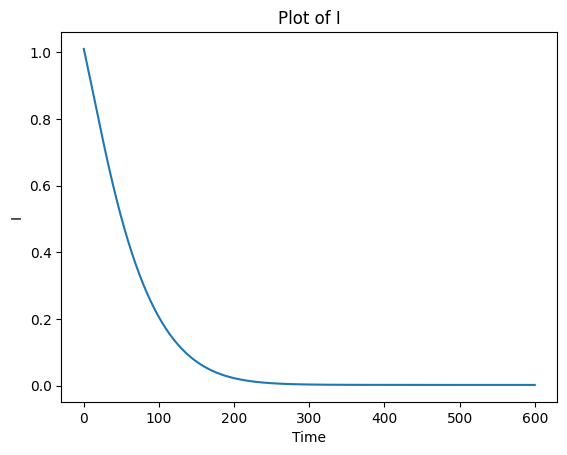

In [15]:
n = np.random.randint(0, len(data_h))
print(n)
print(f"Parameters for n={n}:")
print(f"J_e: {J_e_values[n]}")
print(f"b_1: {b_1_values[n]}")
print(f"b_2: {b_2_values[n]}")
print(f"h_e: {h_e_values[n]}")
print(f"f_0: {f_0_values[n]}")
print(f"P_c: {Pc_values[n]}")
print(f"phi: {phi_values[n]}")

plt.plot(data_c[n])
plt.title('Plot of c')
plt.xlabel('Time')
plt.ylabel('c')
plt.show()

plt.plot(data_h[n])
plt.title('Plot of h')
plt.xlabel('Time')
plt.ylabel('h')
plt.show()

plt.plot(data_f[n])
plt.title('Plot of f')
plt.xlabel('Time')
plt.ylabel('f')
plt.show()

plt.plot(data_I[n])
plt.title('Plot of I')
plt.xlabel('Time')
plt.ylabel('I')
plt.show()